# 04 - Credit Risk EDA, Statistical Analysis, and Portfolio Monitoring

This notebook is the project’s finance-analysis layer. It performs portfolio monitoring, segment-risk analysis, statistical testing, exposure concentration review, proxy-governance monitoring, and train/validation/test stability diagnostics.

**Stage ownership**

- Notebook 01 owns ingestion, schema review, source-sheet reconciliation, and safe merge validation.
- Notebook 02 owns pre-clean data-quality assessment, leakage/proxy review, and cleaning policy evidence.
- Notebook 03 owns cleaning execution, post-clean validation, feature policy, and cleaned dataset creation.
- Notebook 04 owns EDA, statistical analysis, and portfolio monitoring only.

This notebook does **not** fit imputers, encoders, scalers, resampling methods, transformations, or models. Those belong in later modelling notebooks after train/validation/test splitting.


## Stage ownership

| Stage | This notebook owns | Moved elsewhere |
|---|---|---|
| Portfolio overview | Yes | Cleaning belongs to Notebook 03 |
| Target and exposure analysis | Yes | Feature engineering finalization belongs to Notebook 05 |
| Segment-level risk monitoring | Yes | Modelling belongs to Notebook 06 |
| Statistical tests | Yes | Threshold optimization belongs to Notebook 07 |
| Stability diagnostics | Yes, analysis only | Production monitoring plan belongs to governance notebook |
| Sensitive/proxy monitoring | Yes, descriptive only | Model fairness outcomes after predictions |

In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
INTERIM_DIR = DATA_DIR / "interim"
PROCESSED_DIR = DATA_DIR / "processed"
REPORT_DIR = PROJECT_ROOT / "reports"
TABLE_DIR = REPORT_DIR / "tables"
FIGURE_DIR = REPORT_DIR / "figures"

for path in [INTERIM_DIR, PROCESSED_DIR, TABLE_DIR, FIGURE_DIR]:
    path.mkdir(parents=True, exist_ok=True)

TARGET_COL = "defaulter"

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import train_test_split

try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    HAS_STATSMODELS = True
except Exception:
    HAS_STATSMODELS = False

PROCESSED_PATH = PROCESSED_DIR / "credit_risk_cleaned.csv"

if not PROCESSED_PATH.exists():
    raise FileNotFoundError(
        f"Cleaned dataset not found at {PROCESSED_PATH}. Run Notebook 03 or scripts/run_cleaning_pipeline.py first."
    )

df = pd.read_csv(PROCESSED_PATH, low_memory=False)
df.shape

(134417, 46)

## 1. Utility functions for EDA only

In [2]:
def save_table(table: pd.DataFrame, file_name: str, *, float_format: str | None = None) -> pd.DataFrame:
    """Save a DataFrame to reports/tables and return it for display."""
    path = TABLE_DIR / file_name
    path.parent.mkdir(parents=True, exist_ok=True)
    table.to_csv(path, index=False, float_format=float_format)
    return table


def safe_divide(num, den):
    """Vectorized division that returns NaN when the denominator is zero."""
    return np.where(den != 0, num / den, np.nan)


def is_binary_series(s: pd.Series) -> bool:
    """Return True only when a non-empty series contains binary 0/1 values."""
    non_null = s.dropna()
    if non_null.empty:
        return False
    unique_values = set(non_null.unique())
    return len(unique_values) <= 2 and unique_values.issubset({0, 1})


def identify_mathematical_numeric_columns(
    data: pd.DataFrame,
    target_col: str = TARGET_COL,
    exclude_cols: set[str] | None = None,
    low_cardinality_threshold: int = 15,
) -> tuple[list[str], pd.DataFrame]:
    """
    Identify numeric columns suitable for mathematical EDA.

    Excludes:
    - target
    - identifiers/audit keys
    - binary flags
    - low-cardinality integer codes/ordinals

    This avoids treating IDs, flags, and ordinal codes as continuous variables
    in correlation, skewness, outlier, statistical-test, and stability sections.
    """
    exclude_cols = exclude_cols or set()
    default_exclusions = {
        target_col,
        "user_id",
        "record_sequence",
        "_original_row_number",
    }

    rows = []
    math_cols = []

    for col in data.select_dtypes(include="number").columns:
        s = data[col]
        non_null = s.dropna()
        unique_count = int(non_null.nunique())
        unique_ratio = unique_count / len(non_null) if len(non_null) else 0

        is_binary = is_binary_series(s)
        is_integer_like = pd.api.types.is_integer_dtype(s) or (
            len(non_null) > 0 and np.all(np.isclose(non_null, np.round(non_null)))
        )
        is_low_cardinality_integer = unique_count <= low_cardinality_threshold and is_integer_like
        is_identifier = col in default_exclusions or col in exclude_cols or col.endswith("_id")
        include = not (is_identifier or is_binary or is_low_cardinality_integer)

        if col == target_col:
            inferred_type = "target"
        elif is_identifier:
            inferred_type = "identifier_or_audit_key"
        elif is_binary:
            inferred_type = "binary_flag"
        elif is_low_cardinality_integer:
            inferred_type = "low_cardinality_numeric_or_ordinal"
        else:
            inferred_type = "mathematical_numeric"

        rows.append({
            "column": col,
            "dtype": str(s.dtype),
            "non_null_count": int(s.notna().sum()),
            "missing_count": int(s.isna().sum()),
            "missing_pct": round(s.isna().mean() * 100, 2),
            "unique_values": unique_count,
            "unique_ratio": round(unique_ratio, 4),
            "inferred_type": inferred_type,
            "include_in_numeric_eda": include,
        })

        if include:
            math_cols.append(col)

    review = pd.DataFrame(rows).sort_values(
        ["include_in_numeric_eda", "inferred_type", "column"],
        ascending=[False, True, True],
    ).reset_index(drop=True)

    return math_cols, review


def infer_column_roles(data: pd.DataFrame, target_col: str = TARGET_COL) -> pd.DataFrame:
    """Create a compact data dictionary for EDA and governance review."""
    rows = []

    for col in data.columns:
        s = data[col]
        is_numeric = pd.api.types.is_numeric_dtype(s)
        is_binary = is_numeric and is_binary_series(s)
        unique_count = int(s.nunique(dropna=True))

        if col == target_col:
            role = "target"
        elif col in ["user_id", "record_sequence"] or col.endswith("_id"):
            role = "identifier_or_audit_key"
        elif col.endswith("_flag") or col.startswith("has_"):
            role = "quality_or_binary_flag"
        elif col in ["total_payment", "received_principal", "interest_received"]:
            role = "repayment_monitoring_only"
        elif col in ["gender", "pincode", "social_profile"]:
            role = "sensitive_or_proxy_monitoring"
        elif is_binary:
            role = "binary_numeric"
        elif is_numeric:
            role = "numeric"
        else:
            role = "categorical"

        rows.append({
            "column": col,
            "dtype": str(s.dtype),
            "role": role,
            "missing_count": int(s.isna().sum()),
            "missing_pct": round(s.isna().mean() * 100, 2),
            "unique_values": unique_count,
        })

    return pd.DataFrame(rows)


def segment_risk_table(
    data: pd.DataFrame,
    segment_col: str,
    target_col: str = TARGET_COL,
    amount_col: str = "amount",
    min_rows: int = 100,
) -> pd.DataFrame:
    """Default-rate and exposure profile for one segment column."""
    if segment_col not in data.columns or target_col not in data.columns:
        return pd.DataFrame()

    temp = data[[segment_col, target_col] + ([amount_col] if amount_col in data.columns else [])].copy()
    temp[segment_col] = temp[segment_col].astype("object").where(temp[segment_col].notna(), "Missing")

    agg_dict = {
        "row_count": (segment_col, "size"),
        "default_count": (target_col, "sum"),
    }

    if amount_col in temp.columns:
        agg_dict["total_exposure"] = (amount_col, "sum")
        agg_dict["average_exposure"] = (amount_col, "mean")

    out = (
        temp.groupby(segment_col, dropna=False)
        .agg(**agg_dict)
        .reset_index()
        .rename(columns={segment_col: "segment_value"})
    )

    out["segment_column"] = segment_col
    out["default_rate_pct"] = (out["default_count"] / out["row_count"] * 100).round(2)
    out["row_share_pct"] = (out["row_count"] / len(data) * 100).round(2)

    if "total_exposure" in out.columns:
        total_exposure = out["total_exposure"].sum()
        out["exposure_share_pct"] = (safe_divide(out["total_exposure"], total_exposure) * 100).round(2)

    out["meets_min_rows"] = out["row_count"] >= min_rows

    preferred_order = [
        "segment_column",
        "segment_value",
        "row_count",
        "row_share_pct",
        "default_count",
        "default_rate_pct",
        "total_exposure",
        "exposure_share_pct",
        "average_exposure",
        "meets_min_rows",
    ]
    return out[[c for c in preferred_order if c in out.columns]].sort_values(
        ["default_rate_pct", "row_count"],
        ascending=False,
    ).reset_index(drop=True)


def numeric_quantile_risk_table(
    data: pd.DataFrame,
    numeric_col: str,
    target_col: str = TARGET_COL,
    bins: int = 10,
) -> pd.DataFrame:
    """Default-rate profile across quantile bands for one numeric feature."""
    if numeric_col not in data.columns or target_col not in data.columns:
        return pd.DataFrame()

    temp = data[[numeric_col, target_col]].dropna().copy()
    if temp[numeric_col].nunique() < 3:
        return pd.DataFrame()

    try:
        temp["quantile_band"] = pd.qcut(temp[numeric_col], q=bins, duplicates="drop")
    except ValueError:
        return pd.DataFrame()

    out = (
        temp.groupby("quantile_band", observed=False)
        .agg(
            row_count=(target_col, "size"),
            min_value=(numeric_col, "min"),
            max_value=(numeric_col, "max"),
            mean_value=(numeric_col, "mean"),
            default_count=(target_col, "sum"),
            default_rate_pct=(target_col, "mean"),
        )
        .reset_index()
    )

    out["column"] = numeric_col
    out["default_rate_pct"] = (out["default_rate_pct"] * 100).round(2)

    return out[
        ["column", "quantile_band", "row_count", "min_value", "max_value", "mean_value", "default_count", "default_rate_pct"]
    ].round(4)


def cramers_v_from_crosstab(crosstab: pd.DataFrame) -> float:
    """Cramér's V association strength for a contingency table."""
    if crosstab.empty:
        return np.nan

    chi2 = stats.chi2_contingency(crosstab)[0]
    n = crosstab.sum().sum()

    if n == 0:
        return np.nan

    r, k = crosstab.shape
    denom = n * (min(k - 1, r - 1))

    return np.sqrt(chi2 / denom) if denom > 0 else np.nan


def psi(expected: pd.Series, actual: pd.Series, bins: int = 10) -> float:
    """Population Stability Index using expected-distribution quantile bins."""
    expected = pd.Series(expected).replace([np.inf, -np.inf], np.nan).dropna()
    actual = pd.Series(actual).replace([np.inf, -np.inf], np.nan).dropna()

    if expected.empty or actual.empty or expected.nunique() <= 1:
        return np.nan

    breakpoints = expected.quantile(np.linspace(0, 1, bins + 1)).drop_duplicates().values

    if len(breakpoints) <= 2:
        return np.nan

    expected_bins = pd.cut(expected, bins=breakpoints, include_lowest=True, duplicates="drop")
    actual_bins = pd.cut(actual, bins=breakpoints, include_lowest=True, duplicates="drop")

    expected_pct = expected_bins.value_counts(normalize=True, sort=False)
    actual_pct = actual_bins.value_counts(normalize=True, sort=False)

    expected_pct, actual_pct = expected_pct.align(actual_pct, fill_value=0)

    expected_pct = expected_pct.replace(0, 0.0001)
    actual_pct = actual_pct.replace(0, 0.0001)

    return float(((actual_pct - expected_pct) * np.log(actual_pct / expected_pct)).sum())


def hhi_from_series(s: pd.Series) -> float:
    """Herfindahl-Hirschman Index for concentration of a categorical distribution."""
    shares = s.astype("object").where(s.notna(), "Missing").value_counts(normalize=True, dropna=False)
    return float((shares ** 2).sum())


def gini_from_series(s: pd.Series) -> float:
    """Gini concentration metric for non-negative numeric exposure values."""
    x = np.asarray(pd.Series(s).dropna(), dtype=float)
    x = x[x >= 0]

    if len(x) == 0 or np.all(x == 0):
        return np.nan

    x = np.sort(x)
    n = len(x)

    return float((2 * np.sum(np.arange(1, n + 1) * x) / (n * np.sum(x))) - (n + 1) / n)


## 2. Business questions and output map

In [3]:
question_output_map = pd.DataFrame([
    {"business_question": "What is the overall default rate and class imbalance?", "output_table": "04_portfolio_overview.csv"},
    {"business_question": "Which borrower/loan segments have elevated default risk?", "output_table": "04_segment_risk_all.csv"},
    {"business_question": "Where is portfolio exposure concentrated?", "output_table": "04_segment_risk_all.csv / 04_concentration_metrics.csv"},
    {"business_question": "Are missingness and data-quality flags associated with default?", "output_table": "04_flag_risk_profile.csv"},
    {"business_question": "Which numerical variables differ between defaults and non-defaults?", "output_table": "04_numeric_vs_target_tests.csv"},
    {"business_question": "Which categorical variables are associated with default?", "output_table": "04_categorical_vs_target_tests.csv"},
    {"business_question": "Which variables are redundant or highly correlated?", "output_table": "04_correlation_pairs.csv / 04_vif_review.csv"},
    {"business_question": "Which sensitive/proxy groups require governance monitoring?", "output_table": "04_sensitive_proxy_monitoring.csv"},
    {"business_question": "Are train/validation/test splits stable?", "output_table": "04_split_stability_numeric.csv / 04_split_target_stability.csv"},
    {"business_question": "Which findings should move to feature engineering and modelling?", "output_table": "04_eda_action_register.csv"},
])
save_table(question_output_map, "04_business_question_output_map.csv")
question_output_map

,business_question,output_table
0,What is the overall default rate and class imbalance?,04_portfolio_overview.csv
1,Which borrower/loan segments have elevated default risk?,04_segment_risk_all.csv
2,Where is portfolio exposure concentrated?,04_segment_risk_all.csv / 04_concentration_metrics.csv
3,Are missingness and data-quality flags associated with default?,04_flag_risk_profile.csv
4,Which numerical variables differ between defaults and non-defaults?,04_numeric_vs_target_tests.csv
5,Which categorical variables are associated with default?,04_categorical_vs_target_tests.csv
6,Which variables are redundant or highly correlated?,04_correlation_pairs.csv / 04_vif_review.csv
7,Which sensitive/proxy groups require governance monitoring?,04_sensitive_proxy_monitoring.csv
8,Are train/validation/test splits stable?,04_split_stability_numeric.csv / 04_split_target_stability.csv
9,Which findings should move to feature engineering and modelling?,04_eda_action_register.csv


## 3. Column inventory and governance roles

In [4]:
column_roles = infer_column_roles(df)
save_table(column_roles, "04_column_roles.csv")
column_roles

,column,dtype,role,missing_count,missing_pct,unique_values
0,user_id,int64,identifier_or_audit_key,0,0.0000,133752
1,loan_category,object,categorical,0,0.0000,7
2,amount,float64,numeric,27638,20.5600,86156
3,interest_rate,float64,numeric,0,0.0000,137
4,tenure_years,int64,numeric,0,0.0000,2
5,record_sequence,int64,identifier_or_audit_key,0,0.0000,2
6,employment_type,object,categorical,0,0.0000,3
7,tier_of_employment,object,categorical,0,0.0000,8
8,industry,object,categorical,0,0.0000,12974
9,role,object,categorical,0,0.0000,46


## 4. Executive portfolio overview

In [5]:
portfolio_overview = pd.DataFrame({
    "metric": [
        "row_count",
        "column_count",
        "default_count",
        "non_default_count",
        "default_rate_pct",
        "amount_non_null_count",
        "total_exposure",
        "average_amount",
        "median_amount",
        "defaulted_exposure",
        "defaulted_exposure_share_pct",
    ],
    "value": [
        df.shape[0],
        df.shape[1],
        int((df[TARGET_COL] == 1).sum()),
        int((df[TARGET_COL] == 0).sum()),
        round((df[TARGET_COL] == 1).mean() * 100, 4),
        int(df["amount"].notna().sum()) if "amount" in df.columns else np.nan,
        round(df["amount"].sum(skipna=True), 2) if "amount" in df.columns else np.nan,
        round(df["amount"].mean(skipna=True), 2) if "amount" in df.columns else np.nan,
        round(df["amount"].median(skipna=True), 2) if "amount" in df.columns else np.nan,
        round(df.loc[df[TARGET_COL] == 1, "amount"].sum(skipna=True), 2) if "amount" in df.columns else np.nan,
        round(df.loc[df[TARGET_COL] == 1, "amount"].sum(skipna=True) / df["amount"].sum(skipna=True) * 100, 4) if "amount" in df.columns and df["amount"].sum(skipna=True) else np.nan,
    ],
})
save_table(portfolio_overview, "04_portfolio_overview.csv")
portfolio_overview

,metric,value
0,row_count,"134,417.0000"
1,column_count,46.0000
2,default_count,"12,153.0000"
3,non_default_count,"122,264.0000"
4,default_rate_pct,9.0413
5,amount_non_null_count,"106,779.0000"
6,total_exposure,"14,698,519,888.0000"
7,average_amount,"137,653.6600"
8,median_amount,"76,549.0000"
9,defaulted_exposure,"876,761,833.0000"


## 5. Target distribution chart

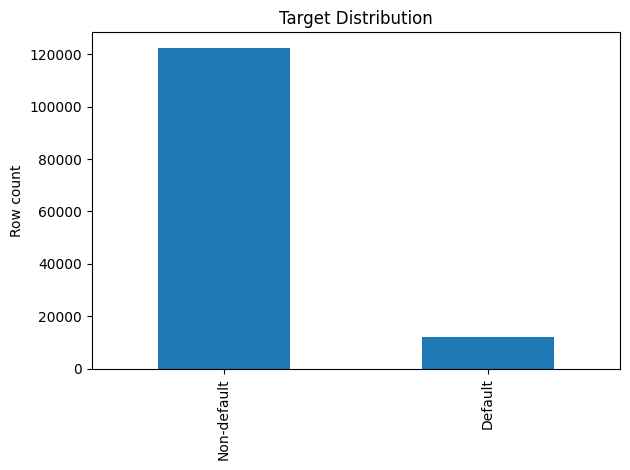

,defaulter,row_count,class_label,share_pct
0,0,122264,Non-default,90.9587
1,1,12153,Default,9.0413


In [6]:
target_distribution = (
    df[TARGET_COL]
    .value_counts()
    .rename_axis(TARGET_COL)
    .reset_index(name="row_count")
)
target_distribution["class_label"] = target_distribution[TARGET_COL].map({0: "Non-default", 1: "Default"})
target_distribution["share_pct"] = (target_distribution["row_count"] / len(df) * 100).round(4)

save_table(target_distribution, "04_target_distribution.csv")

ax = target_distribution.sort_values(TARGET_COL).plot(
    x="class_label",
    y="row_count",
    kind="bar",
    legend=False,
    title="Target Distribution"
)
ax.set_xlabel("")
ax.set_ylabel("Row count")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "04_target_distribution.png", dpi=150)
plt.show()

target_distribution

## 6. Missingness and data-quality risk analysis

In [7]:
flag_cols = [col for col in df.columns if col.endswith("_flag") or col.startswith("has_")]
count_cols = [col for col in df.columns if col.endswith("_issue_count") or col.endswith("_missing_count")]

flag_profile_rows = []
for col in flag_cols:
    if pd.api.types.is_numeric_dtype(df[col]) and set(df[col].dropna().unique()).issubset({0, 1}):
        grouped = df.groupby(col)[TARGET_COL].agg(["count", "sum", "mean"]).reset_index()
        for _, row in grouped.iterrows():
            flag_profile_rows.append({
                "flag": col,
                "flag_value": row[col],
                "row_count": int(row["count"]),
                "default_count": int(row["sum"]),
                "default_rate_pct": round(row["mean"] * 100, 2),
            })

flag_risk_profile = pd.DataFrame(flag_profile_rows)
if not flag_risk_profile.empty:
    flag_risk_profile = flag_risk_profile.sort_values(["flag", "flag_value"])

save_table(flag_risk_profile, "04_flag_risk_profile.csv")
flag_risk_profile

,flag,flag_value,row_count,default_count,default_rate_pct
8,amount_missing_flag,0.0000,106779,7696,7.2100
9,amount_missing_flag,1.0000,27638,4457,16.1300
0,amount_missing_raw_flag,0.0000,106798,7699,7.2100
1,amount_missing_raw_flag,1.0000,27619,4454,16.1300
2,amount_non_positive_flag,0.0000,134398,12150,9.0400
3,amount_non_positive_flag,1.0000,19,3,15.7900
10,employment_type_missing_flag,0.0000,54731,5470,9.9900
11,employment_type_missing_flag,1.0000,79686,6683,8.3900
28,has_broad_data_quality_issue,0.0000,17890,2657,14.8500
29,has_broad_data_quality_issue,1.0000,116527,9496,8.1500


## 7. Numeric profile, skewness, and outlier monitoring

In [8]:
# NUMERIC PROFILE, SKEWNESS, AND OUTLIER MONITORING
# EDA only: do not cap, remove, or transform outliers here.

math_numeric_cols, numeric_eda_review = identify_mathematical_numeric_columns(df)

print(f"Mathematical numeric columns selected for EDA: {len(math_numeric_cols)}")

numeric_profile = pd.DataFrame()

if math_numeric_cols:
    numeric_profile = (
        df[math_numeric_cols]
        .replace([np.inf, -np.inf], np.nan)
        .agg(["count", "mean", "median", "std", "min", "max", "skew", "kurt"])
        .T
        .reset_index()
        .rename(columns={"index": "column"})
        .round(4)
    )

outlier_rows = []

for col in math_numeric_cols:
    s = df[col].replace([np.inf, -np.inf], np.nan).dropna()

    if s.empty:
        continue

    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    below_iqr_count = int((s < lower).sum())
    above_iqr_count = int((s > upper).sum())
    iqr_outlier_count = below_iqr_count + above_iqr_count

    outlier_rows.append({
        "column": col,
        "non_null_count": int(s.shape[0]),
        "mean": round(s.mean(), 4),
        "median": round(s.median(), 4),
        "std": round(s.std(), 4),
        "min": round(s.min(), 4),
        "p01": round(s.quantile(0.01), 4),
        "p05": round(s.quantile(0.05), 4),
        "q1": round(q1, 4),
        "q3": round(q3, 4),
        "p95": round(s.quantile(0.95), 4),
        "p99": round(s.quantile(0.99), 4),
        "max": round(s.max(), 4),
        "iqr_lower_bound": round(lower, 4),
        "iqr_upper_bound": round(upper, 4),
        "below_iqr_count": below_iqr_count,
        "above_iqr_count": above_iqr_count,
        "iqr_outlier_count": iqr_outlier_count,
        "iqr_outlier_pct": round(iqr_outlier_count / len(s) * 100, 2),
        "above_p99_count": int((s > s.quantile(0.99)).sum()),
        "above_p99_pct": round((s > s.quantile(0.99)).mean() * 100, 2),
        "recommended_action": "Review in EDA; final treatment belongs after train/test split",
    })

outlier_review = pd.DataFrame(outlier_rows)

if not outlier_review.empty:
    outlier_review = outlier_review.sort_values(
        ["iqr_outlier_pct", "above_p99_pct"],
        ascending=False,
    ).reset_index(drop=True)

save_table(numeric_eda_review, "04_numeric_eda_column_review.csv")
save_table(numeric_profile, "04_numeric_profile.csv", float_format="%.4f")
save_table(outlier_review, "04_outlier_review.csv", float_format="%.4f")

display(numeric_eda_review)
display(numeric_profile)
display(outlier_review)


Mathematical numeric columns selected for EDA: 11


,column,dtype,non_null_count,missing_count,missing_pct,unique_values,unique_ratio,inferred_type,include_in_numeric_eda
0,amount,float64,106779,27638,20.5600,86156,0.8069,mathematical_numeric,True
1,delinq_2yrs,int64,134417,0,0.0000,22,0.0002,mathematical_numeric,True
2,interest_rate,float64,134417,0,0.0000,137,0.0010,mathematical_numeric,True
3,interest_received,float64,134417,0,0.0000,93862,0.6983,mathematical_numeric,True
4,interest_to_amount_ratio,float64,106779,27638,20.5600,106695,0.9992,mathematical_numeric,True
5,loan_to_income_ratio,float64,106779,27638,20.5600,104531,0.9789,mathematical_numeric,True
6,payment_to_amount_ratio,float64,106779,27638,20.5600,106764,0.9999,mathematical_numeric,True
7,principal_to_amount_ratio,float64,106779,27638,20.5600,106248,0.9950,mathematical_numeric,True
8,received_principal,float64,134417,0,0.0000,42022,0.3126,mathematical_numeric,True
9,total_income_pa,float64,134417,0,0.0000,11380,0.0847,mathematical_numeric,True


,column,count,mean,median,std,min,max,skew,kurt
0,amount,"106,779.0000","137,653.6574","76,549.0000","157,599.9759",5.0000,"8,000,078.0000",4.3480,91.3455
1,interest_rate,"134,417.0000",12.0248,11.8400,3.8793,5.4200,23.5400,0.3644,-0.2610
2,total_income_pa,"134,417.0000","72,597.9750","62,000.0000","56,100.0513","4,000.0000","7,141,778.0000",28.7385,"2,781.9412"
3,delinq_2yrs,"134,417.0000",0.2831,0.0000,0.7992,0.0000,22.0000,5.4235,52.9972
4,total_payment,"134,417.0000","10,696.4361","8,061.1400","8,544.3116",0.0000,"57,777.5799",1.6001,2.7399
5,received_principal,"134,417.0000","8,282.6762","5,869.1200","7,184.0165",0.0000,"35,000.0100",1.5556,2.3161
6,interest_received,"134,417.0000","2,335.8745","1,627.0300","2,419.9096",0.0000,"24,205.6200",2.8500,11.6565
7,loan_to_income_ratio,"106,779.0000",1.8033,1.2359,1.5623,0.0001,19.6375,1.1453,1.5088
8,payment_to_amount_ratio,"106,779.0000",0.3692,0.0971,20.0826,0.0000,"6,251.6800",286.5973,"88,143.2881"
9,principal_to_amount_ratio,"106,779.0000",0.2750,0.0693,10.2366,0.0000,"2,819.1720",219.0457,"56,031.8762"


,column,non_null_count,mean,median,std,min,p01,p05,q1,q3,p95,p99,max,iqr_lower_bound,iqr_upper_bound,below_iqr_count,above_iqr_count,iqr_outlier_count,iqr_outlier_pct,above_p99_count,above_p99_pct,recommended_action
0,delinq_2yrs,134417,0.2831,0.0000,0.7992,0.0000,0.0000,0.0000,0.0000,0.0000,2.0000,4.0000,22.0000,0.0000,0.0000,0,23887,23887,17.7700,789,0.5900,Review in EDA; final treatment belongs after train/test split
1,principal_to_amount_ratio,106779,0.2750,0.0693,10.2366,0.0000,0.0037,0.0085,0.0258,0.1883,0.7209,1.5611,"2,819.1720",-0.2178,0.4319,0,11409,11409,10.6800,1068,1.0000,Review in EDA; final treatment belongs after train/test split
2,payment_to_amount_ratio,106779,0.3692,0.0971,20.0826,0.0000,0.0061,0.0133,0.0381,0.2568,0.8911,1.8760,"6,251.6800",-0.2899,0.5849,0,10362,10362,9.7000,1068,1.0000,Review in EDA; final treatment belongs after train/test split
3,interest_to_amount_ratio,106779,0.0927,0.0207,10.5457,0.0000,0.0007,0.0021,0.0078,0.0573,0.1880,0.4177,"3,432.5080",-0.0665,0.1316,0,9756,9756,9.1400,1068,1.0000,Review in EDA; final treatment belongs after train/test split
4,interest_received,134417,"2,335.8745","1,627.0300","2,419.9096",0.0000,97.1316,288.7100,839.5200,"2,889.8800","6,994.7660","12,383.4900","24,205.6200","-2,236.0200","5,965.4200",0,9324,9324,6.9400,1345,1.0000,Review in EDA; final treatment belongs after train/test split
5,total_payment,134417,"10,696.4361","8,061.1400","8,544.3116",0.0000,912.6892,"2,012.9360","4,623.2300","13,940.1600","28,575.8933","40,353.1680","57,777.5799","-9,352.1650","27,915.5550",0,7218,7218,5.3700,1345,1.0000,Review in EDA; final treatment belongs after train/test split
6,received_principal,134417,"8,282.6762","5,869.1200","7,184.0165",0.0000,504.3248,"1,325.5360","3,047.3900","11,325.0000","24,000.0000","35,000.0000","35,000.0100","-9,369.0250","23,741.4150",0,7069,7069,5.2600,10,0.0100,Review in EDA; final treatment belongs after train/test split
7,total_income_pa,134417,"72,597.9750","62,000.0000","56,100.0513","4,000.0000","18,312.3200","27,000.0000","45,000.0000","87,000.0000","150,000.0000","250,000.0000","7,141,778.0000","-18,000.0000","150,000.0000",0,5832,5832,4.3400,1089,0.8100,Review in EDA; final treatment belongs after train/test split
8,amount,106779,"137,653.6574","76,549.0000","157,599.9759",5.0000,"3,570.3400","8,816.0000","28,520.5000","205,482.5000","422,275.3000","659,305.3800","8,000,078.0000","-236,922.5000","470,925.5000",0,3647,3647,3.4200,1068,1.0000,Review in EDA; final treatment belongs after train/test split
9,loan_to_income_ratio,106779,1.8033,1.2359,1.5623,0.0001,0.0728,0.1866,0.5233,2.8413,4.7644,6.3368,19.6375,-2.9537,6.3182,0,1085,1085,1.0200,1068,1.0000,Review in EDA; final treatment belongs after train/test split


## 8. Segment-level risk and exposure monitoring

In [9]:
segment_candidates = [
    "loan_category", "employment_type", "tier_of_employment", "work_experience",
    "home", "married", "is_verified", "amount_missing_flag",
    "has_core_data_quality_issue", "has_broad_data_quality_issue",
]

segment_tables = []
for col in segment_candidates:
    if col in df.columns:
        table = segment_risk_table(df, col, min_rows=100)
        if not table.empty:
            segment_tables.append(table)

segment_risk_all = pd.concat(segment_tables, ignore_index=True) if segment_tables else pd.DataFrame()
high_risk_segments = segment_risk_all.query("meets_min_rows == True").sort_values(
    ["default_rate_pct", "row_count"], ascending=False
).head(30) if not segment_risk_all.empty else pd.DataFrame()

save_table(segment_risk_all, "04_segment_risk_all.csv", float_format="%.4f")
save_table(high_risk_segments, "04_high_risk_segments.csv", float_format="%.4f")

high_risk_segments

,segment_column,segment_value,row_count,row_share_pct,default_count,default_rate_pct,total_exposure,exposure_share_pct,average_exposure,meets_min_rows
10,tier_of_employment,G,256,0.1900,75,29.3000,"29,419,971.0000",0.2000,"163,444.2833",True
11,tier_of_employment,F,1252,0.9300,305,24.3600,"135,447,896.0000",0.9200,"140,360.5140",True
0,loan_category,Business,2236,1.6600,434,19.4100,"173,506,382.0000",1.1800,"136,619.1984",True
12,tier_of_employment,E,3712,2.7600,669,18.0200,"392,339,239.0000",2.6700,"134,500.9390",True
18,work_experience,2-3,1538,1.1400,249,16.1900,"164,623,095.0000",1.1200,"120,162.8431",True
36,amount_missing_flag,1,27638,20.5600,4457,16.1300,0.0000,0.0000,NaN,True
19,work_experience,5-10,8132,6.0500,1236,15.2000,"936,799,126.0000",6.3700,"127,577.1655",True
40,has_broad_data_quality_issue,0,17890,13.3100,2657,14.8500,"2,575,490,332.0000",17.5200,"143,962.5675",True
38,has_core_data_quality_issue,1,30435,22.6400,4506,14.8100,"23,895,480.0000",0.1600,"8,543.2535",True
7,employment_type,Self-Employed,9914,7.3800,1451,14.6400,"661,358,688.0000",4.5000,"130,677.4724",True


## 9. Segment exposure concentration

In [10]:
concentration_rows = []

for col in segment_candidates:
    if col in df.columns:
        row = {
            "segment_column": col,
            "hhi_row_concentration": round(hhi_from_series(df[col]), 6),
        }
        if "amount" in df.columns:
            exposure_by_segment = df.groupby(col, dropna=False)["amount"].sum(min_count=1)
            exposure_share = exposure_by_segment / exposure_by_segment.sum()
            row["hhi_exposure_concentration"] = round(float((exposure_share ** 2).sum()), 6)
            row["top_segment_by_exposure"] = str(exposure_by_segment.idxmax())
            row["top_segment_exposure_share_pct"] = round(float(exposure_share.max() * 100), 2)
        concentration_rows.append(row)

concentration_metrics = pd.DataFrame(concentration_rows).sort_values(
    "hhi_exposure_concentration" if "amount" in df.columns else "hhi_row_concentration",
    ascending=False
)

save_table(concentration_metrics, "04_concentration_metrics.csv")
concentration_metrics

,segment_column,hhi_row_concentration,hhi_exposure_concentration,top_segment_by_exposure,top_segment_exposure_share_pct
7,amount_missing_flag,0.6733,1.0000,0,100.0000
8,has_core_data_quality_issue,0.6497,0.9968,0,99.8400
9,has_broad_data_quality_issue,0.7692,0.7110,1,82.4800
3,work_experience,0.7206,0.6881,Unknown,82.4200
4,home,0.4222,0.6426,Mortgage,78.5500
1,employment_type,0.4681,0.4991,Unknown,62.0700
0,loan_category,0.4257,0.4412,Consolidation,61.2900
2,tier_of_employment,0.3886,0.4171,Unknown,62.0700
5,married,0.3333,0.3334,Unknown,33.6400
6,is_verified,0.2500,0.2500,Unknown,25.4100


## 10. Two-way segment interaction risk

In [11]:
# TWO-WAY SEGMENT INTERACTION RISK
# Uses standardized feature_1/feature_2 columns to avoid sparse NaN columns
# when multiple segment pairs are concatenated.

two_way_pairs = [
    ("loan_category", "employment_type"),
    ("loan_category", "home"),
    ("employment_type", "tier_of_employment"),
    ("loan_category", "amount_missing_flag"),
    ("home", "has_core_data_quality_issue"),
]

two_way_tables = []

for feature_1, feature_2 in two_way_pairs:
    if {feature_1, feature_2, TARGET_COL}.issubset(df.columns):
        temp = df[[feature_1, feature_2, TARGET_COL] + (["amount"] if "amount" in df.columns else [])].copy()

        temp["feature_1"] = feature_1
        temp["feature_2"] = feature_2
        temp["feature_1_value"] = temp[feature_1].astype("object").where(temp[feature_1].notna(), "Missing")
        temp["feature_2_value"] = temp[feature_2].astype("object").where(temp[feature_2].notna(), "Missing")

        grouped = (
            temp.groupby(["feature_1", "feature_1_value", "feature_2", "feature_2_value"], dropna=False)
            .agg(
                row_count=(TARGET_COL, "size"),
                default_count=(TARGET_COL, "sum"),
                default_rate_pct=(TARGET_COL, "mean"),
                total_exposure=("amount", "sum") if "amount" in temp.columns else (TARGET_COL, "size"),
            )
            .reset_index()
        )

        grouped["default_rate_pct"] = (grouped["default_rate_pct"] * 100).round(2)
        grouped["segment_pair"] = f"{feature_1} x {feature_2}"
        two_way_tables.append(grouped)

two_way_segment_risk = pd.concat(two_way_tables, ignore_index=True) if two_way_tables else pd.DataFrame()

if not two_way_segment_risk.empty:
    two_way_segment_risk = (
        two_way_segment_risk
        .query("row_count >= 100")
        .sort_values(["default_rate_pct", "row_count"], ascending=False)
        .reset_index(drop=True)
    )

save_table(two_way_segment_risk, "04_two_way_segment_risk.csv", float_format="%.4f")
two_way_segment_risk.head(30)


,feature_1,feature_1_value,feature_2,feature_2_value,row_count,default_count,default_rate_pct,total_exposure,segment_pair
0,employment_type,Self-Employed,tier_of_employment,F,223,76,34.0800,"17,762,225.0000",employment_type x tier_of_employment
1,employment_type,Self-Employed,tier_of_employment,E,584,164,28.0800,"46,700,587.0000",employment_type x tier_of_employment
2,employment_type,Salaried,tier_of_employment,G,205,57,27.8000,"24,699,594.0000",employment_type x tier_of_employment
3,loan_category,Business,amount_missing_flag,1,966,238,24.6400,0.0000,loan_category x amount_missing_flag
4,employment_type,Salaried,tier_of_employment,F,1029,229,22.2500,"117,685,671.0000",employment_type x tier_of_employment
5,employment_type,Self-Employed,tier_of_employment,D,1342,295,21.9800,"80,130,572.0000",employment_type x tier_of_employment
6,loan_category,Business,home,Own,193,41,21.2400,"11,699,430.0000",loan_category x home
7,loan_category,Medical,employment_type,Self-Employed,110,23,20.9100,"8,641,829.0000",loan_category x employment_type
8,loan_category,Business,employment_type,Self-Employed,279,57,20.4300,"16,193,269.0000",loan_category x employment_type
9,loan_category,Business,employment_type,Salaried,747,147,19.6800,"63,475,410.0000",loan_category x employment_type


## 11. Numeric quantile risk profiles

In [12]:
quantile_candidates = [
    "amount", "interest_rate", "tenure_years", "total_income_pa",
    "loan_to_income_ratio", "payment_to_amount_ratio",
    "principal_to_amount_ratio", "interest_to_amount_ratio",
    "broad_data_quality_issue_count", "core_data_quality_issue_count",
]
quantile_tables = []

for col in quantile_candidates:
    if col in df.columns:
        table = numeric_quantile_risk_table(df, col, bins=10)
        if not table.empty:
            quantile_tables.append(table)

numeric_quantile_risk = pd.concat(quantile_tables, ignore_index=True) if quantile_tables else pd.DataFrame()
save_table(numeric_quantile_risk, "04_numeric_quantile_risk.csv", float_format="%.4f")
numeric_quantile_risk

,column,quantile_band,row_count,min_value,max_value,mean_value,default_count,default_rate_pct
0,amount,"(4.999, 13912.8]",10678,5.0000,"13,912.0000","8,458.6778",834,7.8100
1,amount,"(13912.8, 23460.6]",10678,"13,913.0000","23,460.0000","18,712.2762",908,8.5000
2,amount,"(23460.6, 33985.4]",10678,"23,461.0000","33,985.0000","28,559.0803",888,8.3200
3,amount,"(33985.4, 48617.4]",10678,"33,986.0000","48,617.0000","40,771.9465",852,7.9800
4,amount,"(48617.4, 76549.0]",10678,"48,619.0000","76,549.0000","60,896.7769",830,7.7700
...,...,...,...,...,...,...,...,...
67,interest_to_amount_ratio,"(0.0464, 0.0718]",10678,0.0464,0.0718,0.0579,830,7.7700
68,interest_to_amount_ratio,"(0.0718, 0.124]",10678,0.0718,0.1239,0.0938,739,6.9200
69,interest_to_amount_ratio,"(0.124, 3432.508]",10678,0.1239,"3,432.5080",0.6691,787,7.3700
70,broad_data_quality_issue_count,"(-0.001, 2.0]",106930,0.0000,2.0000,1.6378,8031,7.5100


## 12. Correlation and multicollinearity review

In [13]:
# CORRELATION AND MULTICOLLINEARITY REVIEW
# Uses mathematical numeric columns only.

if "math_numeric_cols" not in globals() or not math_numeric_cols:
    math_numeric_cols, numeric_eda_review = identify_mathematical_numeric_columns(df)

correlation_pairs = pd.DataFrame(
    columns=["feature_1", "feature_2", "pearson_correlation", "spearman_correlation", "abs_pearson"]
)
vif_review = pd.DataFrame(columns=["feature", "vif"])

if len(math_numeric_cols) >= 2:
    numeric_for_corr = df[math_numeric_cols].replace([np.inf, -np.inf], np.nan)

    pearson_corr = numeric_for_corr.corr(method="pearson")
    spearman_corr = numeric_for_corr.corr(method="spearman")

    upper_mask = np.triu(np.ones(pearson_corr.shape), k=1).astype(bool)

    correlation_pairs = (
        pearson_corr.where(upper_mask)
        .stack()
        .reset_index()
        .rename(columns={"level_0": "feature_1", "level_1": "feature_2", 0: "pearson_correlation"})
    )

    spearman_pairs = (
        spearman_corr.where(upper_mask)
        .stack()
        .reset_index()
        .rename(columns={"level_0": "feature_1", "level_1": "feature_2", 0: "spearman_correlation"})
    )

    correlation_pairs = correlation_pairs.merge(
        spearman_pairs,
        on=["feature_1", "feature_2"],
        how="left",
    )
    correlation_pairs["abs_pearson"] = correlation_pairs["pearson_correlation"].abs()
    correlation_pairs = correlation_pairs.sort_values("abs_pearson", ascending=False).round(4)

    if HAS_STATSMODELS:
        vif_data = numeric_for_corr.dropna()

        if len(vif_data) > 1000:
            vif_data = vif_data.sample(1000, random_state=42)

        if vif_data.shape[1] >= 2 and vif_data.shape[0] > vif_data.shape[1]:
            vif_rows = []

            for i, col in enumerate(vif_data.columns):
                try:
                    vif_rows.append({"feature": col, "vif": variance_inflation_factor(vif_data.values, i)})
                except Exception:
                    vif_rows.append({"feature": col, "vif": np.nan})

            vif_review = pd.DataFrame(vif_rows).sort_values("vif", ascending=False).round(4)

save_table(correlation_pairs, "04_correlation_pairs.csv", float_format="%.4f")
save_table(vif_review, "04_vif_review.csv", float_format="%.4f")

display(correlation_pairs.head(20))
display(vif_review)


,feature_1,feature_2,pearson_correlation,spearman_correlation,abs_pearson
53,payment_to_amount_ratio,interest_to_amount_ratio,0.9673,0.8572,0.9673
52,payment_to_amount_ratio,principal_to_amount_ratio,0.9653,0.9796,0.9653
34,total_payment,received_principal,0.9635,0.9576,0.9635
54,principal_to_amount_ratio,interest_to_amount_ratio,0.8676,0.7646,0.8676
6,amount,loan_to_income_ratio,0.7396,0.9024,0.7396
35,total_payment,interest_received,0.6669,0.6564,0.6669
14,interest_rate,interest_received,0.5129,0.4805,0.5129
1,amount,total_income_pa,0.4941,0.5379,0.4941
40,received_principal,interest_received,0.4506,0.4660,0.4506
20,total_income_pa,total_payment,0.2606,0.3606,0.2606


,feature,vif
8,payment_to_amount_ratio,"10,092.3907"
9,principal_to_amount_ratio,"8,158.0607"
4,total_payment,"1,097.2489"
5,received_principal,697.4120
10,interest_to_amount_ratio,163.2924
6,interest_received,75.5890
0,amount,8.7767
7,loan_to_income_ratio,8.0728
1,interest_rate,6.8244
2,total_income_pa,5.1449


## 13. Numeric features vs target statistical tests

In [14]:
# NUMERIC FEATURES VS TARGET STATISTICAL TESTS
# Mann-Whitney, Welch t-test, Cohen's d, and point-biserial correlation.

if "math_numeric_cols" not in globals() or not math_numeric_cols:
    math_numeric_cols, numeric_eda_review = identify_mathematical_numeric_columns(df)

numeric_test_rows = []

for col in math_numeric_cols:
    non_default = df.loc[df[TARGET_COL] == 0, col].replace([np.inf, -np.inf], np.nan).dropna()
    default = df.loc[df[TARGET_COL] == 1, col].replace([np.inf, -np.inf], np.nan).dropna()

    if len(non_default) < 30 or len(default) < 30:
        continue

    try:
        u_stat, mw_p = stats.mannwhitneyu(default, non_default, alternative="two-sided")
    except Exception:
        u_stat, mw_p = np.nan, np.nan

    try:
        t_stat, t_p = stats.ttest_ind(default, non_default, equal_var=False, nan_policy="omit")
    except Exception:
        t_stat, t_p = np.nan, np.nan

    pooled_std = np.sqrt((default.var() + non_default.var()) / 2)
    cohens_d = (default.mean() - non_default.mean()) / pooled_std if pooled_std and pd.notna(pooled_std) else np.nan

    try:
        valid_idx = df[col].replace([np.inf, -np.inf], np.nan).notna() & df[TARGET_COL].notna()
        point_biserial_r, point_biserial_p = stats.pointbiserialr(df.loc[valid_idx, TARGET_COL], df.loc[valid_idx, col])
    except Exception:
        point_biserial_r, point_biserial_p = np.nan, np.nan

    numeric_test_rows.append({
        "feature": col,
        "non_default_mean": non_default.mean(),
        "default_mean": default.mean(),
        "mean_difference": default.mean() - non_default.mean(),
        "non_default_median": non_default.median(),
        "default_median": default.median(),
        "median_difference": default.median() - non_default.median(),
        "mann_whitney_u_statistic": u_stat,
        "mann_whitney_p_value": mw_p,
        "welch_t_statistic": t_stat,
        "welch_ttest_p_value": t_p,
        "cohens_d": cohens_d,
        "point_biserial_r": point_biserial_r,
        "point_biserial_p_value": point_biserial_p,
    })

numeric_vs_target_tests = pd.DataFrame(numeric_test_rows)

if not numeric_vs_target_tests.empty:
    numeric_vs_target_tests = (
        numeric_vs_target_tests
        .sort_values("point_biserial_r", key=lambda s: s.abs(), ascending=False)
        .round(6)
        .reset_index(drop=True)
    )

save_table(numeric_vs_target_tests, "04_numeric_vs_target_tests.csv", float_format="%.6f")
numeric_vs_target_tests


,feature,non_default_mean,default_mean,mean_difference,non_default_median,default_median,median_difference,mann_whitney_u_statistic,mann_whitney_p_value,welch_t_statistic,welch_ttest_p_value,cohens_d,point_biserial_r,point_biserial_p_value
0,received_principal,"8,719.1332","3,891.7464","-4,827.3867","6,100.0000","2,624.8600","-3,475.1400","373,926,156.5000",0.0000,-119.3570,0.0000,-0.8293,-0.1927,0.0000
1,interest_rate,11.8091,14.1944,2.3853,11.7300,13.8300,2.1000,"1,000,836,247.5000",0.0000,65.0879,0.0000,0.6218,0.1763,0.0000
2,total_payment,"11,053.2978","7,106.2657","-3,947.0321","8,379.7052","5,131.9400","-3,247.7652","502,228,651.5000",0.0000,-63.7976,0.0000,-0.5227,-0.1325,0.0000
3,total_income_pa,"73,439.1883","64,135.0361","-9,304.1521","62,500.0000","55,000.0000","-7,500.0000","644,750,890.5000",0.0000,-23.8007,0.0000,-0.1893,-0.0476,0.0000
4,amount,"139,496.7659","113,924.3546","-25,572.4113","78,520.0000","58,169.5000","-20,350.5000","348,092,560.0000",0.0000,-16.6060,0.0000,-0.1770,-0.0420,0.0000
5,loan_to_income_ratio,1.8121,1.6898,-0.1223,1.2576,1.0053,-0.2523,"366,330,966.0000",0.0000,-6.8156,0.0000,-0.0795,-0.0202,0.0000
6,delinq_2yrs,0.2859,0.2548,-0.0311,0.0000,0.0000,0.0000,"730,187,229.5000",0.0000,-4.3061,0.0000,-0.0399,-0.0112,0.0000
7,principal_to_amount_ratio,0.2881,0.1056,-0.1825,0.0727,0.0338,-0.0390,"268,131,285.0000",0.0000,-5.2688,0.0000,-0.0242,-0.0046,0.1319
8,interest_received,"2,333.8509","2,356.2334",22.3825,"1,639.5300","1,485.7200",-153.8100,"706,187,429.5000",0.0000,0.9110,0.3623,0.0089,0.0027,0.3308
9,payment_to_amount_ratio,0.3835,0.1848,-0.1987,0.0992,0.0720,-0.0271,"325,279,784.0000",0.0000,-2.9278,0.0034,-0.0135,-0.0026,0.4032


## 14. Categorical features vs target statistical tests

In [15]:
# CATEGORICAL FEATURES VS TARGET STATISTICAL TESTS
# Chi-square and Cramér's V for non-numeric categoricals plus binary flags.

categorical_cols = df.select_dtypes(include=["object", "category", "string", "bool"]).columns.tolist()
categorical_test_features = list(dict.fromkeys(categorical_cols + flag_cols))

categorical_test_rows = []

for col in categorical_test_features:
    if col not in df.columns or col == TARGET_COL:
        continue

    temp = df[[col, TARGET_COL]].copy()
    temp[col] = temp[col].astype("object").where(temp[col].notna(), "Missing")

    unique_count = temp[col].nunique(dropna=False)

    if unique_count < 2 or unique_count > 1000:
        continue

    ct = pd.crosstab(temp[col], temp[TARGET_COL])

    if ct.shape[0] < 2 or ct.shape[1] < 2:
        continue

    try:
        chi2, p_value, dof, expected = stats.chi2_contingency(ct)
        cramers_v = cramers_v_from_crosstab(ct)
    except Exception:
        chi2, p_value, dof, cramers_v = np.nan, np.nan, np.nan, np.nan

    rates = temp.groupby(col, dropna=False)[TARGET_COL].mean()

    categorical_test_rows.append({
        "feature": col,
        "unique_values": int(unique_count),
        "chi_square": chi2,
        "p_value": p_value,
        "degrees_of_freedom": dof,
        "cramers_v": cramers_v,
        "min_default_rate_pct": round(rates.min() * 100, 2),
        "max_default_rate_pct": round(rates.max() * 100, 2),
        "default_rate_spread_pct": round((rates.max() - rates.min()) * 100, 2),
    })

categorical_vs_target_tests = pd.DataFrame(categorical_test_rows)

if not categorical_vs_target_tests.empty:
    categorical_vs_target_tests = (
        categorical_vs_target_tests
        .sort_values(["cramers_v", "default_rate_spread_pct"], ascending=False)
        .round(6)
        .reset_index(drop=True)
    )

save_table(categorical_vs_target_tests, "04_categorical_vs_target_tests.csv", float_format="%.6f")
categorical_vs_target_tests


,feature,unique_values,chi_square,p_value,degrees_of_freedom,cramers_v,min_default_rate_pct,max_default_rate_pct,default_rate_spread_pct
0,amount_missing_flag,2,"2,122.6043",0.0000,1,0.1257,7.2100,16.1300,8.9200
1,amount_missing_raw_flag,2,"2,120.9058",0.0000,1,0.1256,7.2100,16.1300,8.9200
2,has_core_data_quality_issue,2,"1,588.5628",0.0000,1,0.1087,7.3500,14.8100,7.4500
3,tier_of_employment,8,"1,518.9311",0.0000,7,0.1063,4.0800,29.3000,25.2200
4,pincode,844,"1,139.5005",0.0000,843,0.0921,0.0000,100.0000,100.0000
5,work_experience,7,940.7672,0.0000,6,0.0837,8.0200,16.1900,8.1700
6,industry_missing_flag,2,924.3638,0.0000,1,0.0829,8.0200,14.6000,6.5700
7,work_experience_missing_flag,2,924.3638,0.0000,1,0.0829,8.0200,14.6000,6.5700
8,industry_placeholder_zero_flag,2,923.6411,0.0000,1,0.0829,8.0200,14.5900,6.5700
9,work_experience_placeholder_zero_flag,2,923.6411,0.0000,1,0.0829,8.0200,14.5900,6.5700


## 15. Categorical-vs-categorical association review

In [16]:
cat_assoc_candidates = [col for col in categorical_cols if df[col].nunique(dropna=True) <= 50]
cat_assoc_rows = []

for i, col_a in enumerate(cat_assoc_candidates):
    for col_b in cat_assoc_candidates[i + 1:]:
        temp = df[[col_a, col_b]].fillna("Missing").astype(str)
        ct = pd.crosstab(temp[col_a], temp[col_b])
        if ct.shape[0] < 2 or ct.shape[1] < 2:
            continue
        try:
            cat_assoc_rows.append({
                "feature_1": col_a,
                "feature_2": col_b,
                "cramers_v": cramers_v_from_crosstab(ct),
                "feature_1_unique": int(temp[col_a].nunique()),
                "feature_2_unique": int(temp[col_b].nunique()),
            })
        except Exception:
            pass

categorical_association_review = pd.DataFrame(cat_assoc_rows)
if not categorical_association_review.empty:
    categorical_association_review = categorical_association_review.sort_values("cramers_v", ascending=False).round(6)

save_table(categorical_association_review, "04_categorical_association_review.csv", float_format="%.6f")
categorical_association_review.head(30)

,feature_1,feature_2,cramers_v,feature_1_unique,feature_2_unique
9,employment_type,tier_of_employment,0.7081,3,8
27,role,home,0.1544,46,4
11,employment_type,work_experience,0.1099,3,7
6,loan_category,home,0.0801,7,4
32,work_experience,home,0.0529,7,4
1,loan_category,tier_of_employment,0.0426,7,8
18,tier_of_employment,work_experience,0.0367,8,7
2,loan_category,role,0.0357,7,46
10,employment_type,role,0.0355,3,46
24,role,work_experience,0.0335,46,7


## 16. Sensitive/proxy variable monitoring

In [17]:
proxy_candidates = ["gender", "married", "dependents", "home", "pincode", "social_profile", "is_verified"]
proxy_tables = []

for col in proxy_candidates:
    if col in df.columns:
        table = segment_risk_table(df, col, min_rows=100)
        if not table.empty:
            table["governance_note"] = "Descriptive monitoring only; do not use high-risk proxy fields in first baseline model."
            proxy_tables.append(table)

sensitive_proxy_monitoring = pd.concat(proxy_tables, ignore_index=True) if proxy_tables else pd.DataFrame()
save_table(sensitive_proxy_monitoring, "04_sensitive_proxy_monitoring.csv", float_format="%.4f")
sensitive_proxy_monitoring.head(40)

,segment_column,segment_value,row_count,row_share_pct,default_count,default_rate_pct,total_exposure,exposure_share_pct,average_exposure,meets_min_rows,governance_note
0,gender,Other,44850,33.3700,4091,9.1200,"4,907,790,001.0000",33.3900,"138,049.2813",True,Descriptive monitoring only; do not use high-risk proxy fields in first baseline model.
1,gender,Female,44898,33.4000,4059,9.0400,"4,897,824,415.0000",33.3200,"136,887.2112",True,Descriptive monitoring only; do not use high-risk proxy fields in first baseline model.
2,gender,Male,44669,33.2300,4003,8.9600,"4,892,905,472.0000",33.2900,"138,030.5087",True,Descriptive monitoring only; do not use high-risk proxy fields in first baseline model.
3,married,Unknown,45084,33.5400,4122,9.1400,"4,945,160,700.0000",33.6400,"137,967.2656",True,Descriptive monitoring only; do not use high-risk proxy fields in first baseline model.
4,married,No,44496,33.1000,4009,9.0100,"4,900,894,269.0000",33.3400,"138,447.2519",True,Descriptive monitoring only; do not use high-risk proxy fields in first baseline model.
5,married,Yes,44837,33.3600,4022,8.9700,"4,852,464,919.0000",33.0100,"136,546.8362",True,Descriptive monitoring only; do not use high-risk proxy fields in first baseline model.
6,dependents,2,26838,19.9700,2515,9.3700,"2,934,103,629.0000",19.9600,"137,197.4015",True,Descriptive monitoring only; do not use high-risk proxy fields in first baseline model.
7,dependents,4,26831,19.9600,2485,9.2600,"2,950,167,148.0000",20.0700,"138,006.6028",True,Descriptive monitoring only; do not use high-risk proxy fields in first baseline model.
8,dependents,0,26890,20.0000,2420,9.0000,"2,980,637,684.0000",20.2800,"139,379.8309",True,Descriptive monitoring only; do not use high-risk proxy fields in first baseline model.
9,dependents,1,26731,19.8900,2407,9.0000,"2,877,353,648.0000",19.5800,"136,090.1314",True,Descriptive monitoring only; do not use high-risk proxy fields in first baseline model.


## 17. Repayment-derived monitoring-only analysis

In [18]:
repayment_monitoring_cols = [
    "total_payment", "received_principal", "interest_received",
    "payment_to_amount_ratio", "principal_to_amount_ratio",
    "interest_to_amount_ratio",
    "principal_exceeds_amount_flag",
]
repayment_cols_present = [col for col in repayment_monitoring_cols if col in df.columns]

repayment_monitoring_profile = pd.DataFrame()
if repayment_cols_present:
    repayment_monitoring_profile = (
        df[repayment_cols_present]
        .agg(["count", "mean", "median", "std", "min", "max"])
        .T
        .reset_index()
        .rename(columns={"index": "feature"})
        .round(4)
    )
    repayment_monitoring_profile["modelling_policy"] = "monitoring_only_exclude_from_first_baseline_model"

save_table(repayment_monitoring_profile, "04_repayment_monitoring_profile.csv", float_format="%.4f")
repayment_monitoring_profile

,feature,count,mean,median,std,min,max,modelling_policy
0,total_payment,"134,417.0000","10,696.4361","8,061.1400","8,544.3116",0.0000,"57,777.5799",monitoring_only_exclude_from_first_baseline_model
1,received_principal,"134,417.0000","8,282.6762","5,869.1200","7,184.0165",0.0000,"35,000.0100",monitoring_only_exclude_from_first_baseline_model
2,interest_received,"134,417.0000","2,335.8745","1,627.0300","2,419.9096",0.0000,"24,205.6200",monitoring_only_exclude_from_first_baseline_model
3,payment_to_amount_ratio,"106,779.0000",0.3692,0.0971,20.0826,0.0000,"6,251.6800",monitoring_only_exclude_from_first_baseline_model
4,principal_to_amount_ratio,"106,779.0000",0.2750,0.0693,10.2366,0.0000,"2,819.1720",monitoring_only_exclude_from_first_baseline_model
5,interest_to_amount_ratio,"106,779.0000",0.0927,0.0207,10.5457,0.0000,"3,432.5080",monitoring_only_exclude_from_first_baseline_model
6,principal_exceeds_amount_flag,"134,417.0000",0.0208,0.0000,0.1427,0.0000,1.0000,monitoring_only_exclude_from_first_baseline_model


## 18. Train/validation/test profile stability diagnostics

In [19]:
# TRAIN / VALIDATION / TEST PROFILE STABILITY CHECK
# EDA diagnostic only - final modelling split happens later.

if TARGET_COL not in df.columns:
    raise KeyError(f"Target column '{TARGET_COL}' was not found in df.")

if "math_numeric_cols" not in globals() or not math_numeric_cols:
    math_numeric_cols, numeric_eda_review = identify_mathematical_numeric_columns(df)

print(f"Mathematical numeric columns used for stability check: {len(math_numeric_cols)}")

split_df = df[df[TARGET_COL].notna()].copy()

train_df, temp_df = train_test_split(
    split_df,
    test_size=0.30,
    stratify=split_df[TARGET_COL],
    random_state=42,
)

valid_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df[TARGET_COL],
    random_state=42,
)

split_target_stability = pd.DataFrame([
    {
        "split": "train",
        "row_count": len(train_df),
        "default_count": int(train_df[TARGET_COL].sum()),
        "default_rate_pct": train_df[TARGET_COL].mean() * 100,
    },
    {
        "split": "validation",
        "row_count": len(valid_df),
        "default_count": int(valid_df[TARGET_COL].sum()),
        "default_rate_pct": valid_df[TARGET_COL].mean() * 100,
    },
    {
        "split": "test",
        "row_count": len(test_df),
        "default_count": int(test_df[TARGET_COL].sum()),
        "default_rate_pct": test_df[TARGET_COL].mean() * 100,
    },
]).round(4)

stability_rows = []

for col in math_numeric_cols:
    train_values = train_df[col].replace([np.inf, -np.inf], np.nan).dropna()

    for split_name, split_data in [("validation", valid_df), ("test", test_df)]:
        split_values = split_data[col].replace([np.inf, -np.inf], np.nan).dropna()

        if train_values.empty or split_values.empty:
            ks_stat, ks_p = np.nan, np.nan
        else:
            ks_stat, ks_p = stats.ks_2samp(train_values, split_values)

        stability_rows.append({
            "feature": col,
            "comparison": f"train_vs_{split_name}",
            "train_mean": train_values.mean(),
            "comparison_mean": split_values.mean(),
            "mean_diff": split_values.mean() - train_values.mean(),
            "ks_statistic": ks_stat,
            "ks_p_value": ks_p,
            "psi": psi(train_values, split_values),
        })

split_stability_numeric = pd.DataFrame(
    stability_rows,
    columns=[
        "feature",
        "comparison",
        "train_mean",
        "comparison_mean",
        "mean_diff",
        "ks_statistic",
        "ks_p_value",
        "psi",
    ],
).round(6)

save_table(split_target_stability, "04_split_target_stability.csv", float_format="%.6f")
save_table(split_stability_numeric, "04_split_stability_numeric.csv", float_format="%.6f")

display(split_target_stability)

if split_stability_numeric.empty:
    print("No mathematical numeric columns were available for numeric split-stability review.")
else:
    display(
        split_stability_numeric
        .sort_values("psi", ascending=False, na_position="last")
        .head(30)
    )


Mathematical numeric columns used for stability check: 11


,split,row_count,default_count,default_rate_pct
0,train,94091,8507,9.0412
1,validation,20163,1823,9.0413
2,test,20163,1823,9.0413


,feature,comparison,train_mean,comparison_mean,mean_diff,ks_statistic,ks_p_value,psi
15,loan_to_income_ratio,train_vs_test,1.8055,1.7881,-0.0174,0.0085,0.2952,0.0011
19,principal_to_amount_ratio,train_vs_test,0.2993,0.2296,-0.0697,0.0060,0.7256,0.0011
10,received_principal,train_vs_validation,"8,284.3605","8,345.2752",60.9147,0.0103,0.0568,0.0009
17,payment_to_amount_ratio,train_vs_test,0.4097,0.2867,-0.1230,0.0069,0.5541,0.0008
4,total_income_pa,train_vs_validation,"72,642.2749","72,528.5915",-113.6835,0.0062,0.5477,0.0007
20,interest_to_amount_ratio,train_vs_validation,0.1090,0.0547,-0.0543,0.0061,0.7095,0.0007
18,principal_to_amount_ratio,train_vs_validation,0.2993,0.2078,-0.0914,0.0099,0.1524,0.0007
2,interest_rate,train_vs_validation,12.0168,12.0562,0.0394,0.0089,0.1407,0.0006
8,total_payment,train_vs_validation,"10,695.0977","10,771.9217",76.8240,0.0081,0.2224,0.0006
5,total_income_pa,train_vs_test,"72,642.2749","72,460.6322",-181.6427,0.0049,0.8146,0.0006


## 19. Automated EDA action register

In [20]:
action_rows = []

if not high_risk_segments.empty:
    action_rows.append({
        "area": "Segment risk",
        "finding": "Some segments show elevated default rates.",
        "recommended_action": "Carry high-risk segment findings into feature engineering and business interpretation.",
        "next_notebook": "05_feature_engineering",
    })

if not outlier_review.empty and (outlier_review["iqr_outlier_pct"] > 5).any():
    action_rows.append({
        "area": "Outliers",
        "finding": "Some numeric features have substantial IQR outlier rates.",
        "recommended_action": "Review transformations such as log1p or winsorization after train/test split.",
        "next_notebook": "05/06",
    })

if not correlation_pairs.empty and (correlation_pairs["abs_pearson"] >= 0.80).any():
    action_rows.append({
        "area": "Multicollinearity",
        "finding": "Highly correlated numeric pairs exist.",
        "recommended_action": "Avoid redundant features or review VIF before linear models.",
        "next_notebook": "05/06",
    })

if not categorical_vs_target_tests.empty:
    top_cat = categorical_vs_target_tests.iloc[0]
    action_rows.append({
        "area": "Categorical association",
        "finding": f"{top_cat['feature']} has the strongest Cramér's V association with default in this EDA.",
        "recommended_action": "Review business meaning and encoding policy before modelling.",
        "next_notebook": "05/06",
    })

if not numeric_vs_target_tests.empty:
    top_num = numeric_vs_target_tests.iloc[0]
    action_rows.append({
        "area": "Numeric association",
        "finding": f"{top_num['feature']} differs meaningfully between default and non-default groups.",
        "recommended_action": "Consider as candidate feature if leakage/governance policy allows.",
        "next_notebook": "05/06",
    })

eda_action_register = pd.DataFrame(action_rows)
save_table(eda_action_register, "04_eda_action_register.csv")
eda_action_register

,area,finding,recommended_action,next_notebook
0,Segment risk,Some segments show elevated default rates.,Carry high-risk segment findings into feature engineering and business interpretation.,05_feature_engineering
1,Outliers,Some numeric features have substantial IQR outlier rates.,Review transformations such as log1p or winsorization after train/test split.,05/06
2,Multicollinearity,Highly correlated numeric pairs exist.,Avoid redundant features or review VIF before linear models.,05/06
3,Categorical association,amount_missing_flag has the strongest Cramér's V association with default in this EDA.,Review business meaning and encoding policy before modelling.,05/06
4,Numeric association,received_principal differs meaningfully between default and non-default groups.,Consider as candidate feature if leakage/governance policy allows.,05/06


## 20. Notebook QA checks

These checks confirm that the notebook generated the core EDA and monitoring outputs expected from Notebook 04.


In [21]:
qa_checks = pd.DataFrame([
    {
        "check": "mathematical_numeric_columns_available",
        "status": bool(len(math_numeric_cols) > 0),
        "detail": len(math_numeric_cols),
    },
    {
        "check": "numeric_profile_created",
        "status": not numeric_profile.empty,
        "detail": len(numeric_profile),
    },
    {
        "check": "numeric_vs_target_tests_created",
        "status": not numeric_vs_target_tests.empty,
        "detail": len(numeric_vs_target_tests),
    },
    {
        "check": "correlation_pairs_created",
        "status": not correlation_pairs.empty,
        "detail": len(correlation_pairs),
    },
    {
        "check": "segment_risk_created",
        "status": not segment_risk_all.empty,
        "detail": len(segment_risk_all),
    },
    {
        "check": "split_stability_numeric_created",
        "status": not split_stability_numeric.empty,
        "detail": len(split_stability_numeric),
    },
])

save_table(qa_checks, "04_notebook_qa_checks.csv")
qa_checks


,check,status,detail
0,mathematical_numeric_columns_available,True,11
1,numeric_profile_created,True,11
2,numeric_vs_target_tests_created,True,11
3,correlation_pairs_created,True,55
4,segment_risk_created,True,42
5,split_stability_numeric_created,True,22


## Carry-forward decisions

1. Notebook 05 should create final candidate features, bands, rare-category rules, and leakage-safe feature lists.
2. Notebook 06 should fit imputers, encoders, scalers, transformations, class weights/resampling, and models only after train/validation/test split.
3. Repayment-derived fields remain monitoring-only for the first baseline model.
4. Sensitive/proxy fields remain governance-monitoring fields unless a documented model-governance decision says otherwise.
5. Segment-risk and statistical-test findings should inform feature engineering and stakeholder interpretation, not automatic feature inclusion.